In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

import pygad
from scripts import Optimizer,Character,Chromosome,get_item_set
import json
with open('data/MAPPED_ITEMS.json', 'r') as file:
    items = {i["ankama_id"]: i for i in json.load(file)}

with open('data/MAPPED_SETS.json', 'r') as file:
    item_sets = {i["ankama_id"]: i for i in json.load(file)}

In [2]:
config = {
            "optimizer" : {
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 30%
                "num_generations": 500,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [6894,
                              6895,
                              3080,
                              9031,
                              6980 # Vulbis
                              ]  # Excluded items
                },
                "preferences": {
                    "lower": {
                        12 : 12, # AP
                        8 : 6, # MP
                        # 29 : 75, # Crit
                        28 : 4, # Summon
                        9 : 4000, # Vit
                    },
                    "upper": {} 
                },
                "elements" : [
                    # 36, # Agility,
                    # 22, # Chance
                    # 13, # Intelligence
                    45  # Strength
                ],
                "level_offset": 10,  # Level offset for items
                "objective": "elements",  # Objective to optimize, can be "weapon" or "elements"
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12 : 1, # Exo AP
                    8 : 1, # Exo MP
                    }  
            },
        }
config["language"] = config["optimizer"]["language"]
config["character"]["elements"] = config["optimizer"]["elements"]

In [3]:
import pandas as pd

effect_descriptions = {}
for _,item in items.items():
    if not item["effects"]:
        continue
    for effect in item["effects"]:
        effect_descriptions[effect["element_id"]] = effect["type"]

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["language"]],
        "set" : item_set["name"][config["language"]] if item_set else None,
    }
Items = pd.DataFrame.from_dict(dct, orient='index')

In [4]:
char = Character(**config["character"])
opt = Optimizer(char, items, item_sets, **config["optimizer"])

Total pools: 16 with sizes [69, 118, 71, 71, 62, 81, 40, 88, 69, 412, 326, 326, 326, 326, 326, 326]
Total combinations: 10^34.39


In [13]:
opt.optimize()

In [14]:
print("Best solution fitness:", opt.solution.get_fitness())
print("Best solution weapon damage:", opt.solution.get_final_weapon_damage())
print("Best solution elemental damage:", opt.solution.get_final_elemental_damage())
print("Is the solution viable?", opt.solution.viable)

Best solution fitness: 234.8929
Best solution weapon damage: 0
Best solution elemental damage: 512.4936
Is the solution viable? True


In [7]:
opt.solution.totals_summary(effect_descriptions,
                      language=config["language"])#.sort_values("value",ascending=False)

,description,value
0,Intercambiable:,0.0
8,PM,6.0
9,vitalidad,4200.0
10,sabiduría,445.0
12,PA,11.0
13,inteligencia,380.0
14,de resistencia al fuego,20.0
16,% resistencia al aire,13.0
17,% resistencia al agua,47.0
22,suerte,200.0


In [8]:
set_summary = opt.solution.set_summary(language=config["language"])
set_summary

,type_id,type,description,level,set
739,13,Dofus,Dofus Turquesa,160,None
7043,13,Dofus,Dofus de los hielos,180,None
13673,12,Mascota,Lokulto,20,None
13774,13,Trofeo,Torturador terráqueo mayor,150,None
14161,11,Capa,Capa Ordiosera,200,Set de charlatán
14162,4,Cinturón,Cinto Dovencible,200,Set de charlatán
15431,10,Sombrero,Sombrero de Lonyon,200,Set de Lonyon
15433,1,Amuleto,Amuleto de Lonyon,200,Set de Lonyon
16196,13,Trofeo,Rabioso mayor,150,None
16254,13,Trofeo,Asolador de tierra mayor,150,None


In [9]:
set_summary["set"].value_counts()

set
Set de charlatán              2
Set de Lonyon                 2
Set de kukoloide              1
Set del Corazón Sangriento    1
Set de Cocuzko                1
Set de Corrupción             1
Set de Gargandias             1
Name: count, dtype: int64

In [10]:
from scripts import get_weapon_damage
get_weapon_damage(opt.solution.weapon)

{248: 80, 238: -2, 255: 1}

Text(0, 0.5, 'Best Fitness')

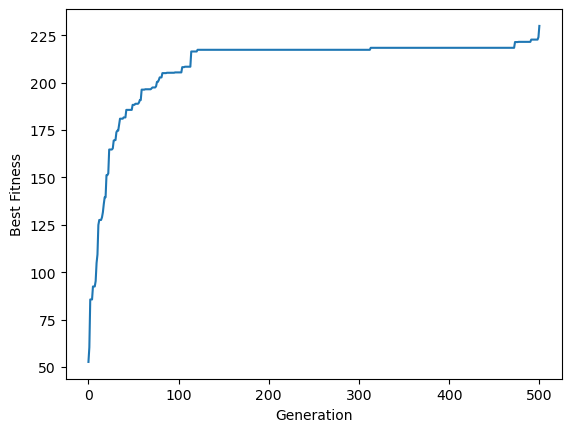

In [11]:
import matplotlib.pyplot as plt
plt.plot(opt.ga_instance.best_solutions_fitness)
plt.xlabel('Generation')
plt.ylabel('Best Fitness')

In [12]:
assert False

AssertionError: 